1. IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import silhouette_score, davies_bouldin_score

2. MOUNT GOOGLE DRIVE

In [2]:
df = pd.read_csv('Mall_Customers.csv')

3. LOAD DATA DARI DRIVE

In [3]:
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


4. PREPROCESSING DATA

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

5. K-MEANS CLUSTERING

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

6. DBSCAN CLUSTERING

In [12]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

7. VISUALISASI HASIL

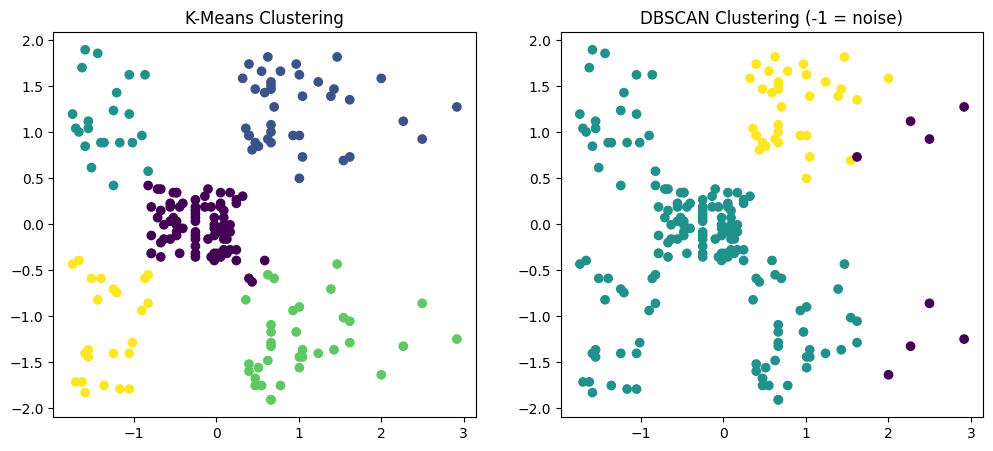

In [7]:
plt.figure(figsize=(12,5))

# KMeans
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")

# DBSCAN
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=dbscan_labels, cmap='viridis')
plt.title("DBSCAN Clustering (-1 = noise)")

plt.show()

8. EVALUASI MODEL

Silhouette Score (semakin besar semakin baik)

In [13]:
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
dbscan_sil = silhouette_score(X_scaled, dbscan_labels)

print("KMeans Silhouette Score :", kmeans_sil)
print("DBSCAN Silhouette Score :", dbscan_sil)

KMeans Silhouette Score : 0.5546571631111091
DBSCAN Silhouette Score : 0.42136463110237615


Davies-Bouldin Index (semakin kecil semakin baik)

In [9]:
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
dbscan_db = davies_bouldin_score(X_scaled, dbscan_labels)

print("KMeans DB Index :", kmeans_db)
print("DBSCAN DB Index :", dbscan_db)

KMeans DB Index : 0.5722356162263352
DBSCAN DB Index : 0.8285103931757107


9. RINGKASAN PERBANDINGAN

In [16]:
print("\n=== PERBANDINGAN MODEL ===")
print(f"KMeans  -> Silhouette: {kmeans_sil:.3f}, DB Index: {kmeans_db:.3f}")
print(f"DBSCAN  -> Silhouette: {dbscan_sil:.3f}, DB Index: {dbscan_db:.3f}")


=== PERBANDINGAN MODEL ===
KMeans  -> Silhouette: 0.555, DB Index: 0.572
DBSCAN  -> Silhouette: 0.421, DB Index: 0.829


ELBOW METHOD (Cari K terbaik KMeans)

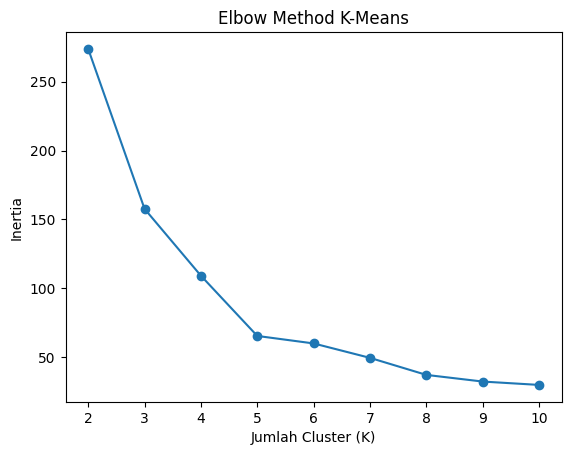

In [17]:
inertia = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method K-Means")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.show()